# Load Packages and Data

In [559]:
import importlib
import pitch_suggestions

importlib.reload(pitch_suggestions)

<module 'pitch_suggestions' from '/Users/kids/Pitcher Similarity/pitch_suggestions.py'>

In [560]:
from data import build_all
from pitch_suggestions import suggest_pitches, plot_pitch_clusters, run_suggest_pitches_bulk
from pitch_suggestions import _find_target, _find_biomech_comps, _collect_pitches, _tag_novelty, _cluster_novel
import warnings
import pandas as pd

from biomech import compute_euclidean_distances

pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

In [88]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

# Identify Pitch Opportunities

In [89]:
BIOMECH_FEATURES    = ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']
PITCH_CHAR_FEATURES = ['release_speed', 'pfx_x', 'pfx_z']

### Bello Example

Example of what the tool recommends

In [516]:
b_bello = suggest_pitches(
    target_pitcher='Bello, Brayan',
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_r,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=False
)

In [303]:
b_bello['status']

'ok'

In [304]:
b_bello['target_info']

pitcher                        678394
p_throws                            R
player_name             Bello, Brayan
game_year                        2025
release_pos_x               -1.657082
release_pos_z                5.323063
release_extension            6.342714
arm_angle                   32.793504
n                                2697
max_velo                    95.301591
max_spin                  2479.262411
pri_fb                             SI
fb_pfx_x                    -1.408565
fb_n                            943.0
pri_fb_cd                           0
active_spin_fastball             80.8
FB_type                            FF
Name: 3714, dtype: object

In [305]:
b_bello['comps'].sort_values('comp_pitcher')[20:25]

,comp_pitcher,comp_year,distance
19,"Beasley, Jeremy",2021,0.538652
209,"Bellatti, Andrew",2023,1.284690
5,"Bello, Brayan",2025,0.379836
274,"Bender, Anthony",2024,1.415107
198,"Berríos, José",2022,1.257038


In [330]:
print(b_bello['comp_pitches'].shape)
b_bello['comp_pitches'].head()

(48, 20)


,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_sil,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label,biomech_distance,sim_weight
0,"Duffey, Tyler",2021,CS,73.983721,0.961163,-1.079070,43,1052,0.040875,2.556191,ST,3,0.417600,0.445221,0.328997,0.111600,1.0,CU,1.135869,0.880382
1,"Scherzer, Max",2021,CU,76.863538,1.120650,-0.661625,277,2821,0.098192,1.810144,ST,4,0.372461,0.404729,0.314113,0.095159,1.0,CU,1.168811,0.855570
2,"Mikolas, Miles",2024,CU,76.587580,0.664395,-1.182548,314,2697,0.116426,2.245386,ST,3,0.371340,0.314477,0.328997,0.111600,1.0,CU,1.306019,0.765685
3,"Smith, Burch",2024,CU,79.996951,0.920366,-1.140183,164,896,0.183036,1.740989,ST,1,0.445674,0.211520,0.313402,0.075482,1.0,CU,1.443101,0.692952
4,"Bard, Luke",2022,CU,78.114583,1.588542,-0.021458,48,241,0.199170,1.714839,ST,2,0.602684,0.329631,0.329631,0.092570,1.0,CU,0.857655,1.165969


In [368]:
b_bello['suggestions']

,cluster_label,cluster,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
0,CU,1,47,78.4,0.94,-1.07,1.94,78.6,0.94,-1.06,0.649,"CS, CU, KC","Antone, Tejay, Avila, Pedro, Barlow, Scott, Ba..."
1,ST,0,12,79.8,0.74,0.27,1.66,79.8,0.66,0.29,0.191,"CH, CU, SL, ST","Adam, Jason, Bard, Luke, Barraclough, Kyle, Ba..."


In [308]:
b_bello['target_pitches']

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Bello, Brayan",2025,CH,88.787073,-1.336869,0.377049,410
1,"Bello, Brayan",2025,FC,88.241371,0.072411,0.215721,423
2,"Bello, Brayan",2025,FF,95.075980,-0.638393,1.126201,408
3,"Bello, Brayan",2025,SI,95.301591,-1.408565,0.471697,943
4,"Bello, Brayan",2025,ST,85.676608,0.825887,-0.265263,513


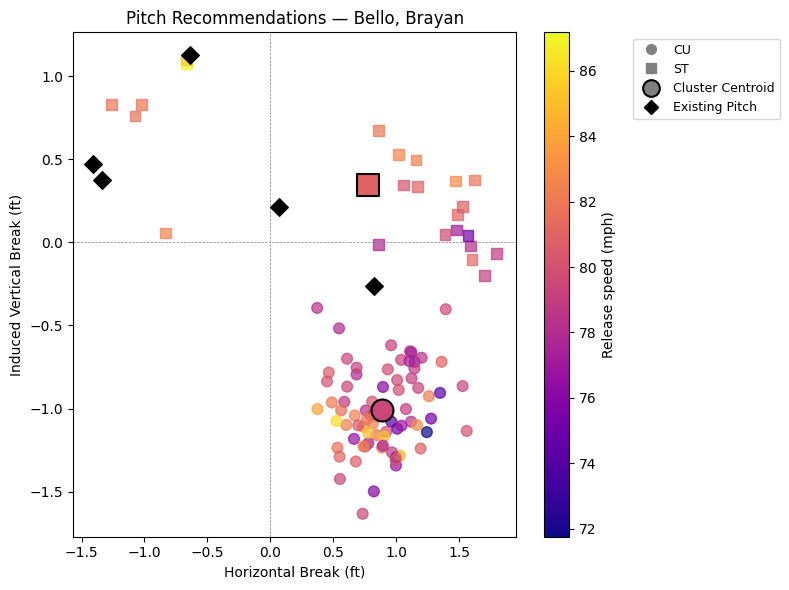

In [517]:
plot_pitch_clusters(b_bello)

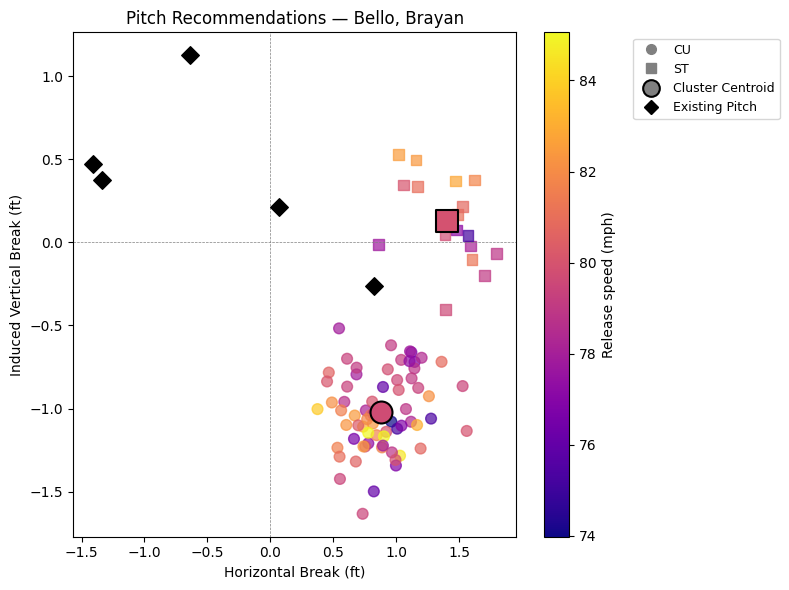

In [513]:
plot_pitch_clusters(b_bello)

In [515]:
b_bello['comp_pitches'].sort_values('_dist_to_centroid', ascending=False)

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_sil,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label,biomech_distance,sim_weight
0,"Duffey, Tyler",2021,CS,73.983721,0.961163,-1.079070,43,1052,0.040875,2.289734,ST,0,0.480515,0.972031,0.540745,0.142131,1.0,CU,1.135869,0.880382
26,"France, J.P.",2023,CU,76.013576,0.821954,-1.498841,302,2202,0.137148,2.394526,ST,0,0.581065,0.926491,0.540745,0.142131,1.0,CU,1.437784,0.695514
60,"Nelson, Jimmy",2021,KC,85.056667,0.902556,-1.167667,180,523,0.344168,1.293088,ST,0,0.523574,0.924733,0.540745,0.142131,1.0,CU,1.344642,0.743692
66,"Schmidt, Clarke",2025,KC,85.017489,0.777489,-1.146099,223,1226,0.181892,1.261135,ST,0,0.531086,0.919665,0.540745,0.142131,1.0,CU,1.171794,0.853391
39,"Nance, Tommy",2024,CU,84.568595,1.030165,-1.283719,121,322,0.375776,1.482836,ST,0,0.538920,0.917428,0.540745,0.142131,1.0,CU,0.827279,1.208781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,"Smith, Burch",2024,CU,79.996951,0.920366,-1.140183,164,896,0.183036,1.574829,ST,0,0.699955,0.184582,0.540745,0.142131,1.0,CU,1.443101,0.692952
6,"Taillon, Jameson",2021,CU,80.702428,0.848543,-1.047991,453,2372,0.190978,1.394694,ST,0,0.691922,0.176322,0.540745,0.142131,1.0,CU,1.378091,0.725641
43,"Burnes, Corbin",2025,CU,80.033505,0.809021,-0.958557,194,1009,0.192270,1.370430,ST,0,0.677855,0.133574,0.540745,0.142131,1.0,CU,1.052448,0.950165
77,"Eflin, Zach",2023,ST,79.710377,1.386509,0.045189,106,2577,0.041133,1.282713,ST,1,0.658057,0.126824,0.534619,0.101949,1.0,ST,1.191653,0.839170


### Step Guide

In [547]:
target_row, target_year = _find_target(pitcher_summ_l, 'Beeks, Jalen')

In [548]:
target_dists = _find_biomech_comps(
    pitcher_summ_l, 'Beeks, Jalen', target_year,
    BIOMECH_FEATURES, biomech_distance_threshold=1.5, min_pitches=20,
)

In [549]:
target_pitches, comp_pitches = _collect_pitches(
    pitch_type_l, target_pitcher='Beeks, Jalen', target_year=target_year, target_dists=target_dists,
    pitch_features=PITCH_CHAR_FEATURES, min_comp_usage_pct=0.01, min_pitches=20
)

In [550]:
from sklearn.preprocessing import StandardScaler
global_scaler = StandardScaler().fit(
    pitch_type_l[PITCH_CHAR_FEATURES].dropna().values
)

In [561]:
comp_pitches, novel = _tag_novelty(
    target_pitches, comp_pitches, PITCH_CHAR_FEATURES, novelty_distance_threshold=1.2, global_scaler=global_scaler
)

In [562]:
print(novel.shape)
novel.head()

(101, 11)


,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch
2,"Alvarez, Jose",2021,CH,81.165441,1.201103,0.359853,272,970,0.280412,1.463415,CH
14,"Gomber, Austin",2022,CH,82.039227,0.814779,0.878923,362,2059,0.175814,1.297258,CH
20,"Means, John",2021,CH,83.392114,1.070599,1.413675,634,2328,0.272337,1.298609,CH
40,"Montgomery, Jordan",2021,CH,82.484505,0.811470,1.225719,626,2570,0.243580,1.366072,CH
41,"Suarez, José",2025,CH,83.341667,1.266190,0.266071,84,295,0.284746,1.228495,CH


In [563]:
novel = _cluster_novel(novel, global_scaler, PITCH_CHAR_FEATURES)

Silhouette score for k=2: 0.625
Silhouette score for k=3: 0.383
Silhouette score for k=4: 0.410
Silhouette score for k=5: 0.454
Silhouette score for k=6: 0.417
Silhouette score for k=7: 0.417
Silhouette score for k=8: 0.402
Silhouette score for k=2: 0.648
Silhouette score for k=3: 0.370
Silhouette score for k=4: 0.414
Silhouette score for k=5: 0.462
Silhouette score for k=6: 0.423
Silhouette score for k=7: 0.382
Silhouette score for k=8: 0.422
Silhouette score for k=2: 0.664
Silhouette score for k=3: 0.387
Silhouette score for k=4: 0.426
Silhouette score for k=5: 0.449
Silhouette score for k=6: 0.406
Silhouette score for k=7: 0.368
Silhouette score for k=8: 0.397
Silhouette score for k=2: 0.676
Silhouette score for k=3: 0.403
Silhouette score for k=4: 0.442
Silhouette score for k=5: 0.437
Silhouette score for k=6: 0.396
Silhouette score for k=7: 0.319
Silhouette score for k=8: 0.342
Silhouette score for k=2: 0.681
Silhouette score for k=3: 0.408
Silhouette score for k=4: 0.447
Silhouet

In [555]:
novel

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_sil,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label
0,"Alvarez, Jose",2021,CH,81.165441,1.201103,0.359853,272,970,0.280412,1.463415,CH,1,0.537757,1.176168,1.035685,0.161289,1.519551,CH
1,"Gomber, Austin",2022,CH,82.039227,0.814779,0.878923,362,2059,0.175814,1.297258,CH,1,0.665790,0.654165,1.035685,0.161289,1.519551,CH
2,"Means, John",2021,CH,83.392114,1.070599,1.413675,634,2328,0.272337,1.298609,CH,1,0.629014,1.220050,1.035685,0.161289,1.519551,CH
3,"Montgomery, Jordan",2021,CH,82.484505,0.811470,1.225719,626,2570,0.243580,1.366072,CH,1,0.651129,0.906973,1.035685,0.161289,1.519551,CH
4,"Suarez, José",2025,CH,83.341667,1.266190,0.266071,84,295,0.284746,1.228495,CH,1,0.536502,1.155413,1.035685,0.161289,1.519551,CH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,"Ragans, Cole",2025,KC,80.087681,-0.960580,-1.088188,138,1079,0.127896,2.030740,FC,0,0.754300,0.537573,0.629107,0.186234,1.187809,CU
85,"Cleavinger, Garrett",2023,SL,81.329293,-1.025960,-0.596061,99,211,0.469194,1.452851,FC,0,0.632267,0.876354,0.629107,0.186234,1.187809,CU
86,"Skubal, Tarik",2022,SL,89.345008,-0.092978,0.683570,591,1914,0.308777,1.253861,FC,1,0.614208,1.021735,1.035685,0.161289,1.519551,CH
87,"Harris, Hogan",2025,ST,78.180000,-0.982571,-0.490571,35,1125,0.031111,1.592499,FC,0,0.667296,0.766629,0.629107,0.186234,1.187809,CU


## Bulk runs

In [244]:
l_bulk = run_suggest_pitches_bulk(pitcher_summ_l, pitch_type_summ, 
                                  min_pitches=20,
                                  biomech_distance_threshold=1.5,  
                                  novelty_distance_threshold=1.5,  
                                  min_comp_usage_pct=0.01)

In [245]:
print(len(l_bulk[0]), "New suggestions for lefties")
l_bulk[0].head()

329 New suggestions for lefties


,target_pitcher,cluster_label,cluster,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
0,"Hill, Rich",SL,0,6,78.8,-1.04,-0.04,1.69,78.9,-1.05,-0.04,0.635,"CU, SL, ST, SV","Díaz, Jhonathan, Fleming, Josh, Guenther, Sean..."
1,"Hill, Rich",SL,2,4,82.2,-0.54,-0.17,1.69,82.1,-0.55,-0.17,0.459,"CU, SL","Alexander, Scott, Alexander, Tyler, Garrett, B..."
2,"Hill, Rich",CU,1,3,79.9,-0.28,-0.51,1.82,79.9,-0.29,-0.51,0.437,"CU, KC","Freeland, Kyle, Quintana, Jose, Zimmermann, Bruce"
3,"Wilson, Justin",CU,0,64,78.7,-0.77,-0.70,2.29,78.4,-0.76,-0.73,0.742,"CU, KC, SL, ST, SV","Abad, Fernando, Abbott, Andrew, Allard, Kolby,..."
4,"Wilson, Justin",SI,1,9,94.0,1.38,0.80,1.60,94.0,1.38,0.80,0.923,SI,"Banuelos, Manny, Borucki, Ryan, Jay, Tyler, Ma..."


In [246]:
l_bulk[1]

,target_pitcher,status,n_comps,n_suggestions
0,"Hill, Rich",ok,33,3
1,"Wilson, Justin",ok,115,2
2,"Kershaw, Clayton",ok,28,2
3,"Miley, Wade",ok,142,2
4,"Quintana, Jose",ok,102,2
...,...,...,...,...
202,"Sommers, Drew",no_comps,0,0
203,"Gibson, Cade",no_novel_pitches,113,0
204,"Early, Connelly",ok,62,2
205,"Farris, Mitch",ok,81,2


In [247]:
l_bulk[0][(l_bulk[0]['_sil'] > 0.3) & (l_bulk[0]['_sil'] < 0.34)]

,target_pitcher,cluster_label,cluster,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
18,"Anderson, Tyler",KC,0,2,76.0,-1.16,-0.29,1.65,76.0,-1.15,-0.31,0.338,"KC, ST","Means, John, Springs, Jeffrey"
28,"Corbin, Patrick",CU,1,12,75.4,-0.82,-1.03,1.73,75.4,-0.82,-1.02,0.321,CU,"Boyd, Matthew, Bush, Ky, Dayton, Grant, Díaz, ..."
96,"Alexander, Tyler",CU,0,29,75.9,-0.86,-0.93,2.32,75.7,-0.87,-0.96,0.336,"CU, KC","Aldegheri, Sam, Allard, Kolby, Boyd, Matthew, ..."
103,"Lauer, Eric",CH,1,2,80.0,1.14,0.66,1.58,80.6,1.14,0.86,0.303,CH,"Farris, Mitch, Means, John"
131,"Newcomb, Sean",CU,0,5,81.1,-0.24,0.11,1.56,81.2,-0.24,0.10,0.335,"CU, KC, SL","Lauer, Eric, Logue, Zach, Smyly, Drew, Suarez,..."
163,"Holton, Tyler",CH,0,3,80.0,0.29,0.52,1.51,79.6,0.24,0.45,0.338,"CH, CU, KC","Holland, Derek, Lucchesi, Joey, Means, John"
211,"Abbott, Andrew",CU,0,2,76.4,-0.58,-1.45,1.81,76.5,-0.59,-1.43,0.315,CU,"Duffy, Danny, Thompson, Zack"
236,"Hurter, Brant",CU,2,3,80.8,-0.31,-0.72,1.66,80.8,-0.33,-0.73,0.305,"CU, KC","Freeland, Kyle, Muller, Kyle, Zimmermann, Bruce"
276,"Vesia, Alex",CU,0,3,77.5,-0.69,-0.76,1.81,77.7,-0.68,-0.75,0.327,CU,"Davidson, Tucker, Garrett, Braxton, Smith, Will"


In [510]:
s_peralta = suggest_pitches(
    target_pitcher='Peralta, Sammy',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [529]:
e_lauer = suggest_pitches(
    target_pitcher='Lauer, Eric',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [524]:
r_hill = suggest_pitches(
    target_pitcher='Hill, Rich',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [534]:
p_corbin = suggest_pitches(
    target_pitcher='Corbin, Patrick',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [538]:
t_alexander = suggest_pitches(
    target_pitcher='Alexander, Tyler',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [564]:
j_beeks = suggest_pitches(
    target_pitcher='Beeks, Jalen',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=False
)

Silhouette score for k=2: 0.625
Silhouette score for k=3: 0.383
Silhouette score for k=4: 0.410
Silhouette score for k=5: 0.454
Silhouette score for k=6: 0.417
Silhouette score for k=7: 0.417
Silhouette score for k=8: 0.402


In [465]:
r_garcia = suggest_pitches(
    target_pitcher='Garcia, Robert',
    pitcher_summ=pitcher_summ_l,        
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

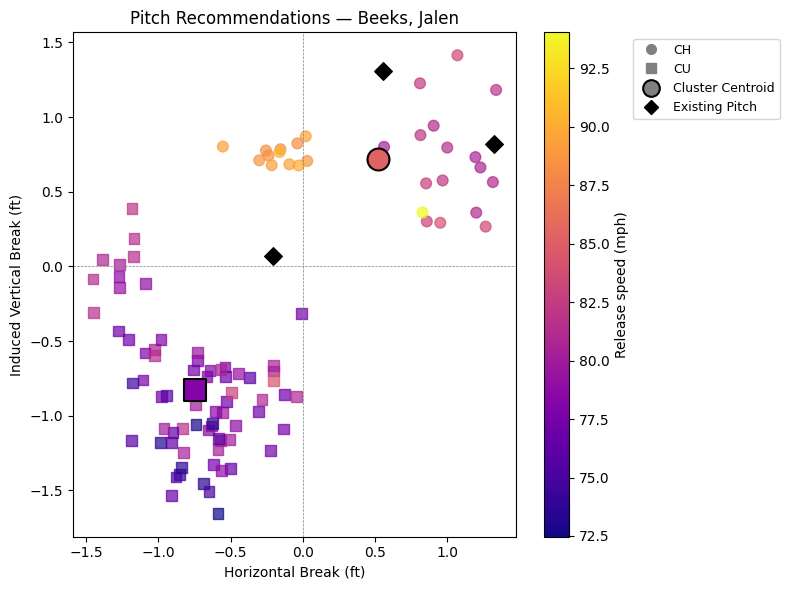

In [546]:
plot_pitch_clusters(j_beeks)

In [533]:
p_corbin['comp_pitches'].sort_values('_dist_to_centroid', ascending=False).head(10)

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_sil,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label,biomech_distance,sim_weight
23,"Gordon, Colton",2025,CU,75.568919,-1.092770,-0.148243,148,1451,0.101999,1.229771,CU,1,0.195766,0.901667,0.499076,0.137385,1.000000,ST,1.181923,0.846078
11,"Irvin, Cole",2024,CU,77.348655,-1.128139,-0.399753,446,1767,0.252405,1.369052,SL,0,-0.028113,0.869225,0.589294,0.145950,1.027143,CU,1.463276,0.683398
16,"Mushinski, Parker",2023,CU,81.733735,-0.834458,-1.085422,83,255,0.325490,1.818371,SL,0,0.472848,0.831267,0.589294,0.145950,1.027143,CU,1.310069,0.763318
7,"Boyd, Matthew",2021,CU,73.503125,-1.042500,-1.319896,96,1272,0.075472,1.989361,CU,0,0.594367,0.826837,0.589294,0.145950,1.027143,CU,1.375785,0.726857
38,"Nardi, Andrew",2022,ST,83.931092,-1.026807,0.436218,119,374,0.318182,1.282631,SL,1,0.597347,0.823170,0.499076,0.137385,1.000000,ST,1.437704,0.695553
36,"Abbott, Andrew",2023,ST,82.949521,-0.976805,0.503323,313,1897,0.164997,1.218240,SL,1,0.605191,0.803850,0.499076,0.137385,1.000000,ST,1.109454,0.901344
28,"Messick, Parker",2025,CU,77.134177,-1.207722,-0.492025,79,625,0.126400,1.522342,SL,0,0.125037,0.790807,0.589294,0.145950,1.027143,CU,1.262123,0.792315
15,"Hentges, Sam",2021,CU,80.222293,-0.587866,-1.225605,314,1260,0.249206,1.901421,SL,0,0.567438,0.748160,0.589294,0.145950,1.027143,CU,1.352458,0.739394
45,"Ferguson, Caleb",2024,SV,81.057895,-0.737632,-0.806947,190,940,0.202128,1.393764,SL,0,0.407252,0.735244,0.589294,0.145950,1.027143,CU,1.239500,0.806776
18,"Holton, Tyler",2025,CU,80.429268,-0.826585,-1.246829,41,1159,0.035375,2.016708,SL,0,0.561400,0.729535,0.589294,0.145950,1.027143,CU,0.769879,1.298904
